In [1]:
pip install torch matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Create a Non-Linear Dataset
from sklearn.datasets import make_moons
import torch

In [4]:
X,y = make_moons(n_samples=200,noise = 0.2, random_state=42)
X = torch.tensor(X,dtype=torch.float32)
y = torch.tensor(y.reshape(-1,1),dtype=torch.float32)

In [7]:
X.shape, y.shape

(torch.Size([200, 2]), torch.Size([200, 1]))

In [10]:
X.dtype

torch.float32

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

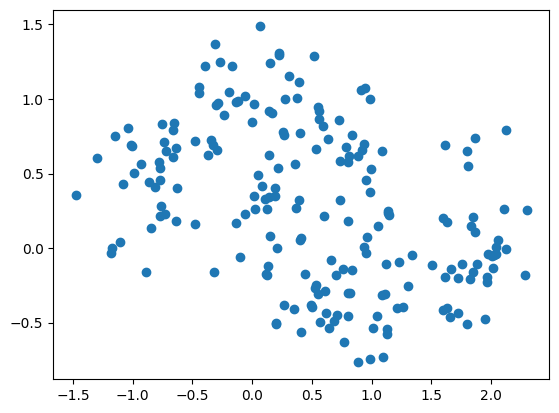

In [13]:
plt.scatter(X[:,0],X[:,1])
plt.show()

In [14]:
# Define Model (Forward = Forward Propagation)

import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2,4)
        self.fc2 = nn.Linear(4,1)

    def forward(self,x):
        z1 = self.fc1(x)  # w1.x + b1
        a1 = torch.relu(z1)  # activation
        z2 = self.fc2(a1)   # w2.a1 + b2
        return torch.sigmoid(z2) # output

In [15]:
# Visualization Function (Decision Boundary)
def plot_boundary(model, X, y, epoch):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    with torch.no_grad():
        preds = model(grid).reshape(xx.shape)

    plt.contourf(xx, yy, preds.numpy(), alpha=0.6)
    plt.scatter(X[:,0], X[:,1], c=y.squeeze(), edgecolors='k')
    plt.title(f"Epoch {epoch}")
    plt.show()


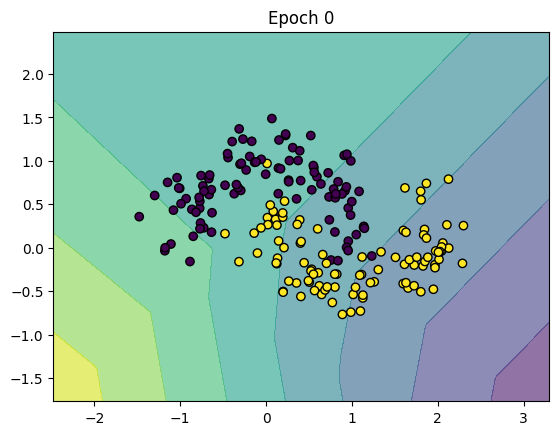

W1: tensor([[ 0.6911, -0.6828],
        [-0.0890, -0.0486],
        [-0.2256, -0.3055],
        [-0.3361, -0.5504]])
b1: tensor([ 0.4220,  0.0167,  0.1464, -0.5393])


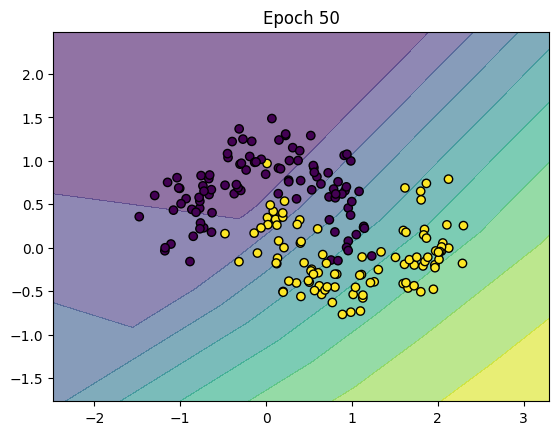

W1: tensor([[ 0.7746, -0.7742],
        [-0.0280, -0.0747],
        [-0.0508, -0.3809],
        [-0.3361, -0.5504]])
b1: tensor([ 0.4928, -0.0249,  0.1899, -0.5393])


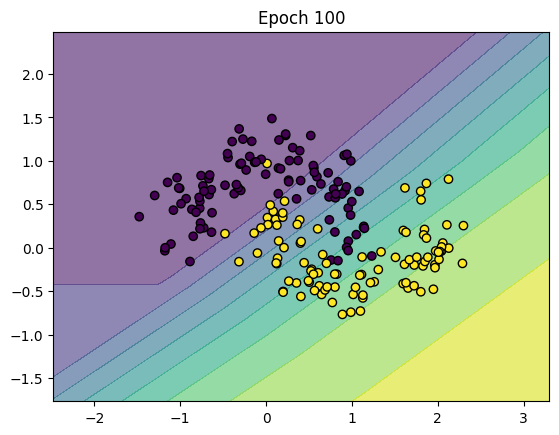

W1: tensor([[ 0.8341, -1.0047],
        [ 0.0202, -0.0979],
        [ 0.0737, -0.4326],
        [-0.3361, -0.5504]])
b1: tensor([ 0.6133,  0.0204,  0.2601, -0.5393])


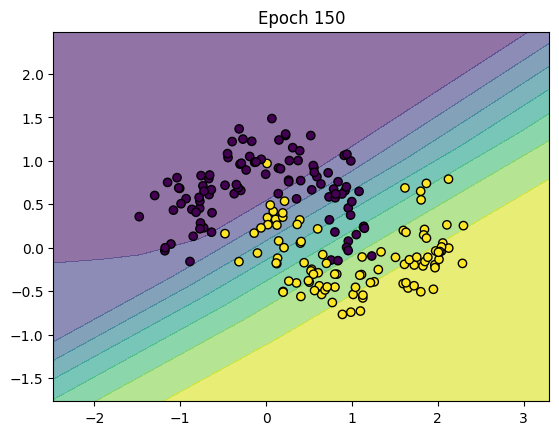

W1: tensor([[ 0.7865, -1.2270],
        [ 0.0508, -0.1330],
        [ 0.1168, -0.4894],
        [-0.3361, -0.5504]])
b1: tensor([ 0.7220,  0.0793,  0.3092, -0.5393])


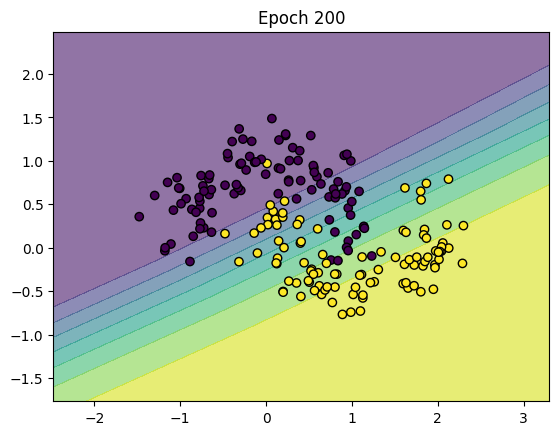

W1: tensor([[ 0.7088, -1.3879],
        [ 0.0546, -0.1687],
        [ 0.1344, -0.5349],
        [-0.3361, -0.5504]])
b1: tensor([ 0.8435,  0.1091,  0.3539, -0.5393])


In [17]:
import numpy as np
model = Net()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
loss_fn = nn.BCELoss()

for epoch in range(0, 201):
    # Forward propagation
    y_pred = model(X)

    # Loss
    loss = loss_fn(y_pred, y)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 🔥 Visualize every 50 steps
    if epoch % 50 == 0:
        plot_boundary(model, X, y, epoch)

        # print weights & bias
        print("W1:", model.fc1.weight.data)
        print("b1:", model.fc1.bias.data)